<a href="https://colab.research.google.com/github/July230/CopyCode/blob/develop/CopyCodeEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CopyCode

CopyCode es una herramienta para poder detectar si un codigo es copiado, no detecta autoría.

## Imports

In [ ]:
from PIL import Image
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.math import confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint
from PIL import Image
import io
from google.colab import files
from transformers import BertTokenizer, BertModel
import re
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


## Split directories

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pwd

/content


In [ ]:
%cd "/content/drive/MyDrive/IA y Compiladores/Reto_plagio/dataset"
!ls

/content/drive/MyDrive/IA y Compiladores/Reto_plagio/dataset
dev  dev.csv  test  tokens_official.csv  train	train.csv  unlabeled_test.csv


## Extracción de datos

In [ ]:
df_train = pd.read_csv("./train.csv")

In [ ]:
df_validation = pd.read_csv("./dev.csv")

In [ ]:
df_test = pd.read_csv("./unlabeled_test.csv")

In [ ]:
df_all = pd.concat([df_train, df_validation, df_test])

## Tokenizar

In [ ]:

tokenizer_bert = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)


def split_text(text, chunk_size=400):

    words = text.split()

    return [
        " ".join(words[i:i+chunk_size])
        for i in range(0, len(words), chunk_size)
    ]




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def generate_tokens(text):

    chunks = split_text(text)

    rows = []

    for idx, chunk in enumerate(chunks):

        tokens = tokenizer_bert(
            chunk,
            padding=True,
            truncation=True,
            max_length=512
        )

        rows.append({
            "chunk_id": idx,

            "token_ids": tokens["input_ids"],

            "tokens": tokenizer_bert.convert_ids_to_tokens(
                tokens["input_ids"]
            ),

            "num_tokens": len(tokens["input_ids"])
        })

    return pd.DataFrame(rows)





In [ ]:
def read_file(path, dataframe):

    all_tokens = []

    #dataframe2 = dataframe.head(50)
    for idx, row in dataframe.iterrows():
    #for idx, row in dataframe2.iterrows():

        id_file = str(row["pid"])

        file_path = os.path.join(path, id_file)

        with open(file_path, "r", encoding="utf-8") as file:

            content = file.read()

            tokens = generate_tokens(content)

            tokens["file_id"] = id_file

            all_tokens.append(tokens)

        if idx % 100 == 0:
            print(f"Processed {idx} files")

    final_df = pd.concat(all_tokens, ignore_index=True)

    final_df.to_csv("./tokens.csv", index=False)

    return final_df

In [ ]:
#content = read_file("./train", df_train)
#content

In [ ]:
!ls

dev  dev.csv  test  tokens_official.csv  train	train.csv  unlabeled_test.csv


In [ ]:
df = pd.read_csv('./tokens_official.csv')


In [ ]:
df.head(4)

,chunk_id,token_ids,tokens,num_tokens,file_id
0,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...","[[CLS], /, *, {, {, {, *, /, #, include, <, cs...",512,27909
1,1,"[101, 1065, 1065, 1065, 20014, 2222, 1027, 101...","[[CLS], }, }, }, int, ll, =, 0, ,, rr, =, nu, ...",360,27909
2,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...","[[CLS], /, *, {, {, {, *, /, #, include, <, cs...",512,55938
3,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...","[[CLS], /, *, {, {, {, *, /, #, include, <, cs...",512,90936


## Info train

In [ ]:
df_train.groupby('uid').count()

,pid
uid,
0,50
1,50
2,50
3,50
4,50
...,...
995,50
996,50
997,50


In [ ]:
df['token_ids'] = df['token_ids'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

all_tokens = [token for sublist in df['token_ids'] for token in sublist]
token_counts = Counter(all_tokens)

df_counts = pd.DataFrame(token_counts.items(), columns=['token_id', 'count'])
df_counts = df_counts.sort_values('count', ascending=False).reset_index(drop=True)


In [ ]:

df['tokens'] = df['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

conjunto_tokens = set(token for sublist in df['tokens'] for token in sublist)

print(conjunto_tokens)
print(f"\nTotal de tokens únicos: {len(conjunto_tokens)}")

{'supporting', 'rattled', 'anyone', 'ro', '##dal', 'iso', '##cia', '747', '295', '##val', 'tay', 'heidi', 'symbolic', 'items', '##urity', '510', 'back', 'because', 'ya', '##zai', 'mv', '##vi', '##alla', 'grades', '##rai', '##rix', 'strict', 'gift', 'xu', 'returning', 'bottle', 'mph', '##hoot', '##eb', 'pounds', 'corresponding', 'need', 'mirror', 'ir', 'pavement', 'sid', 'shouted', 'angles', 'mana', 'hacker', '##ulus', '##ull', 'heaven', 'rebirth', '203', '##bm', 'followed', 'fight', 'aiming', 'equal', 'dad', 'rex', '1926', 'encoding', '1646', 'find', '##aint', 'additional', '##gr', 'mira', 'hal', 'sheet', 'indexed', 'continuing', '##ক', 'harbour', 'submissions', 'xml', 'suspect', 'ford', 'rebuild', '1200', 'outside', 'chain', '840', '##ener', 'crawl', 'binary', '##lli', '##pres', 'gp', 'contiguous', '##mat', 'centered', '##atter', '##ber', 'checking', 'duo', '##ors', 'j', 'shifted', 'proceeding', 'smile', 'complex', '##row', '##be', '51', '670', 'by', 'entries', 'actor', 'ま', 'gaa', 'e

In [ ]:
df_train["uid"].nunique()

1000

In [ ]:
df["num_tokens"].describe()

,num_tokens
count,58790.000000
mean,402.458564
std,140.462649
min,3.000000
25%,294.000000
50%,512.000000
75%,512.000000
max,512.000000


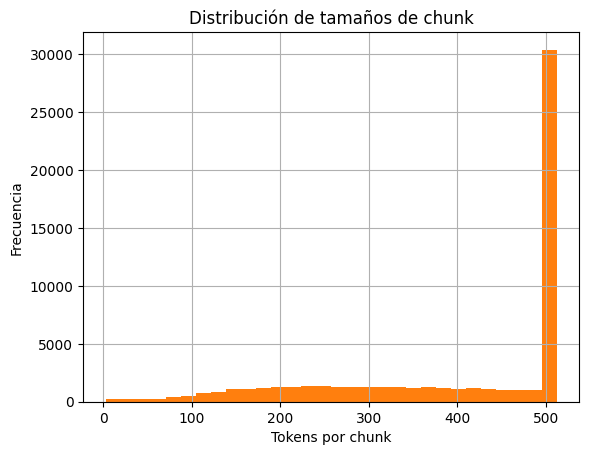

In [ ]:
df["num_tokens"].hist(bins=30)
plt.hist(df['num_tokens'], bins=30)
plt.xlabel('Tokens por chunk')
plt.ylabel('Frecuencia')
plt.title('Distribución de tamaños de chunk')
plt.show()

In [ ]:
counter_per_token = Counter()
for token in df["tokens"]:
  counter_per_token.update(token)



In [ ]:
counter_per_token.most_common(20)

[(';', 1359298),
 ('(', 1247845),
 (')', 1236896),
 ('<', 877201),
 ('=', 810436),
 (',', 734933),
 ('>', 607781),
 ('i', 587286),
 ('#', 563644),
 ('+', 549689),
 ('[', 493803),
 (']', 491524),
 ('int', 487390),
 ('.', 397157),
 ('_', 365969),
 ('{', 326083),
 ('n', 321940),
 ('"', 318647),
 ('-', 318260),
 ('1', 311627)]

In [ ]:
chunks_per_file = df.groupby('file_id').size()

chunks_per_file.describe()

,0
count,50000.000000
mean,1.175800
std,0.732738
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,26.000000


In [ ]:
tokens_per_file = (
    df.groupby('file_id')['num_tokens']
      .sum()
)
tokens_per_file

,num_tokens
file_id,
2,512
3,512
9,512
10,512
13,240
...,...
99993,512
99994,512
99996,442


Vocabulario unico

In [ ]:
file_vocab = {}

for file_id, group in df.groupby('file_id'):

    vocab = set()

    for toks in group['tokens']:
        vocab.update(toks)

    file_vocab[file_id] = len(vocab)

In [ ]:
vocab_sizes = pd.Series(file_vocab)

vocab_sizes.describe()

,0
count,50000.000000
mean,101.516420
std,41.060684
min,8.000000
25%,73.000000
50%,96.000000
75%,123.000000
max,852.000000


In [ ]:
results = []

for file_id, group in df.groupby('file_id'):

    all_tokens = []

    for toks in group['tokens']:
        all_tokens.extend(toks)

    unique_tokens = len(set(all_tokens))
    total_tokens = len(all_tokens)

    ttr = unique_tokens / total_tokens

    results.append({
        'file_id': file_id,
        'ttr': ttr
    })

ttr_df = pd.DataFrame(results)
ttr_df

,file_id,ttr
0,2,0.179688
1,3,0.187500
2,9,0.189453
3,10,0.212891
4,13,0.270833
...,...,...
49995,99993,0.261719
49996,99994,0.228516
49997,99996,0.237557
49998,99998,0.258373


In [ ]:
keywords = [

    # Control flow
    'if',
    'else',
    'switch',
    'case',
    'default',
    'for',
    'while',
    'do',
    'break',
    'continue',
    'return',

    # Object-oriented
    'class',
    'interface',
    'extends',
    'implements',
    'abstract',
    'virtual',
    'override',
    'sealed',
    'base',
    'this',
    'super',
    'new',

    # Access modifiers
    'public',
    'private',
    'protected',
    'internal',
    'static',
    'final',
    'const',
    'readonly',

    # Exception handling
    'try',
    'catch',
    'finally',
    'throw',
    'throws',

    # Types
    'int',
    'float',
    'double',
    'char',
    'boolean',
    'bool',
    'string',
    'String',
    'long',
    'short',
    'byte',
    'decimal',
    'void',
    'var',

    # Memory / references
    'null',
    'nullptr',

    # Namespaces / imports
    'import',
    'package',
    'using',
    'namespace',

    # Concurrency
    'synchronized',
    'volatile',
    'async',
    'await',
    'lock',

    # Misc
    'enum',
    'struct',
    'typedef',
    'typeof',
    'instanceof',
    'sizeof',
    'get',
    'set',
    'yield',
    'lambda'
]

In [ ]:
keyword_counts = Counter()

for toks in df['tokens']:
    for token in toks:
        if token in keywords:
            keyword_counts[token] += 1

keyword_counts

Counter({'string': 34258,
         'set': 23614,
         'int': 487390,
         'for': 156871,
         'get': 12507,
         'case': 1422,
         'using': 60869,
         'long': 139997,
         'double': 28332,
         'while': 28050,
         'if': 149120,
         'else': 35649,
         'return': 101257,
         'class': 13528,
         'void': 31070,
         'base': 18024,
         'break': 7389,
         'continue': 7833,
         'char': 14401,
         'null': 10280,
         'do': 1964,
         'new': 2545,
         'this': 3044,
         'public': 1326,
         'static': 1838,
         'try': 285,
         'float': 848,
         'lambda': 46,
         'private': 457,
         'switch': 58,
         'default': 70,
         'internal': 7,
         'final': 213,
         'throw': 722,
         'sealed': 1,
         'short': 521,
         'finally': 2,
         'var': 1247,
         'virtual': 12,
         'interface': 33,
         'protected': 3,
         'catch': 42

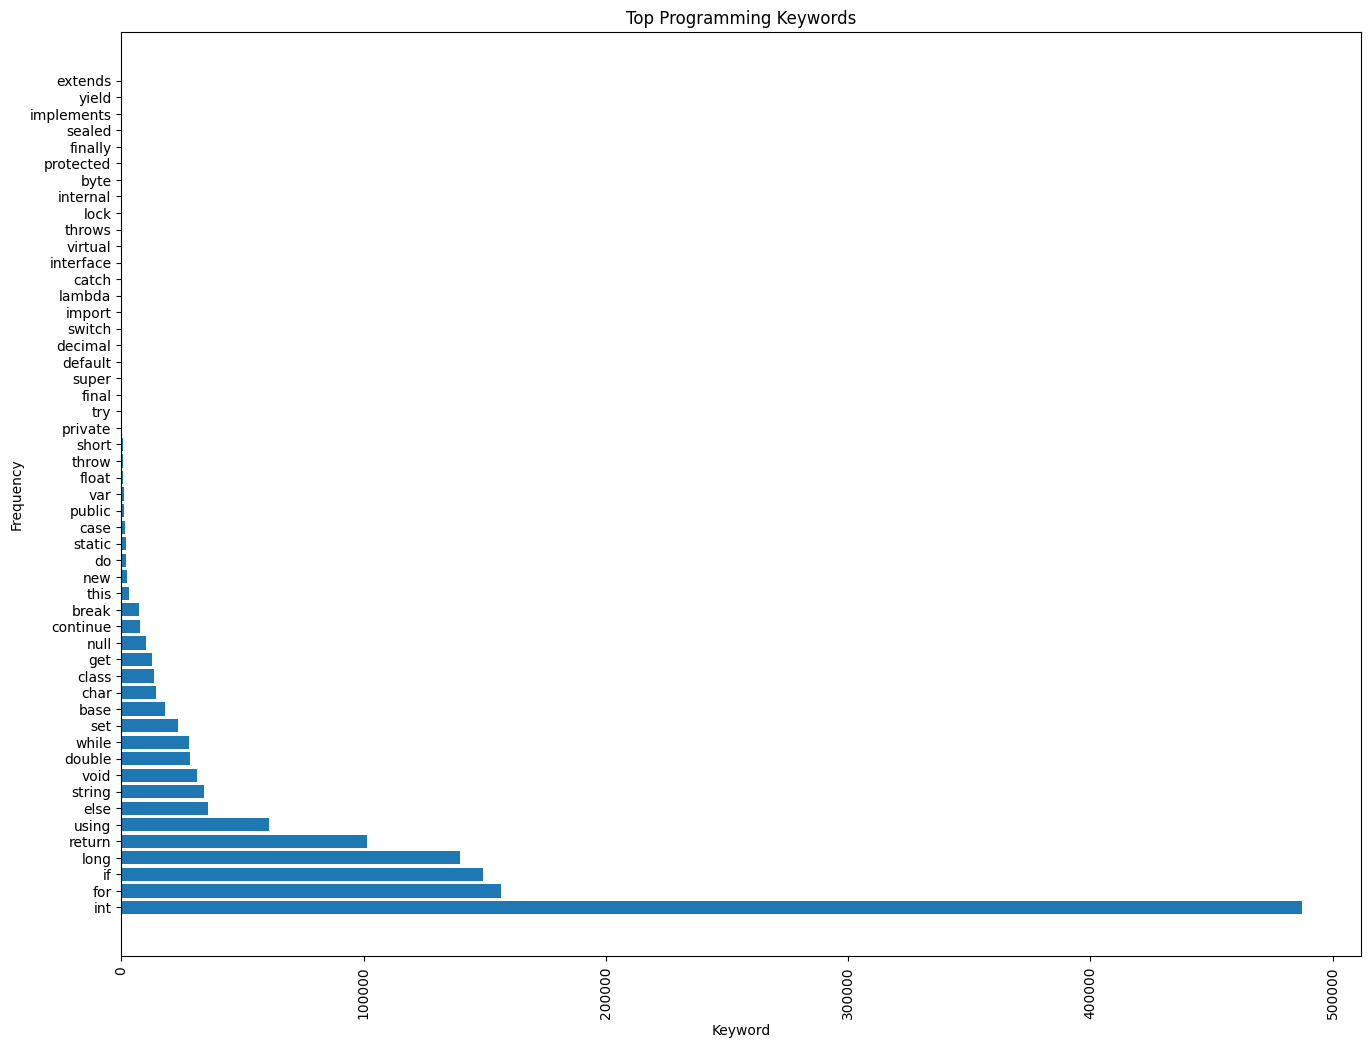

In [ ]:
top_keywords = keyword_counts.most_common()

words = [x[0] for x in top_keywords]
counts = [x[1] for x in top_keywords]

plt.figure(figsize=(16,12))
plt.barh(words, counts)

plt.xticks(rotation=90)
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.title("Top Programming Keywords")

plt.show()

In [ ]:
file_text = (
    df.groupby('file_id')['tokens']
      .apply(lambda x: ' '.join(
          token
          for tokens in x
          for token in tokens
      ))
)

In [ ]:
df_merged = df.merge(
    df_train,
    left_on='file_id',
    right_on='pid',
    how='left'
)

In [ ]:
df_merged.head(2)

,chunk_id,token_ids,tokens,num_tokens,file_id,uid,pid
0,0,"[101, 1013, 1008, 1063, 1063, 1063, 1008, 1013...","[[CLS], /, *, {, {, {, *, /, #, include, <, cs...",512,27909,415,27909
1,1,"[101, 1065, 1065, 1065, 20014, 2222, 1027, 101...","[[CLS], }, }, }, int, ll, =, 0, ,, rr, =, nu, ...",360,27909,415,27909


TOKENS MÁS FRECUENTES GLOBALMENTE

In [ ]:
global_counter = Counter()

for toks in df_merged['tokens']:
    global_counter.update(toks)

print("\n===================================")
print("TOP 20 TOKENS GLOBALES")
print("===================================")

for token, freq in global_counter.most_common(20):
    print(f"{token}: {freq}")




TOP 20 TOKENS GLOBALES
;: 1359298
(: 1247845
): 1236896
<: 877201
=: 810436
,: 734933
>: 607781
i: 587286
#: 563644
+: 549689
[: 493803
]: 491524
int: 487390
.: 397157
_: 365969
{: 326083
n: 321940
": 318647
-: 318260
1: 311627


FRECUENCIA DE OPERADORES

In [ ]:
operators = {
    '+','-','*','/',
    '=','==','!=',
    '<','>','<=','>=',
    '&&','||','%',
    '++','--'
}

operator_counter = Counter()

for toks in df_merged['tokens']:

    filtered = [
        tok for tok in toks
        if tok in operators
    ]

    operator_counter.update(filtered)

top_operators = operator_counter.most_common(20)

print("TOP OPERADORES\n")

for token, freq in top_operators:
    print(f"{token}: {freq}")

TOP OPERADORES

<: 877201
=: 810436
>: 607781
+: 549689
-: 318260
/: 267083
*: 217540
%: 98496


GRAFICAR OPERADORES

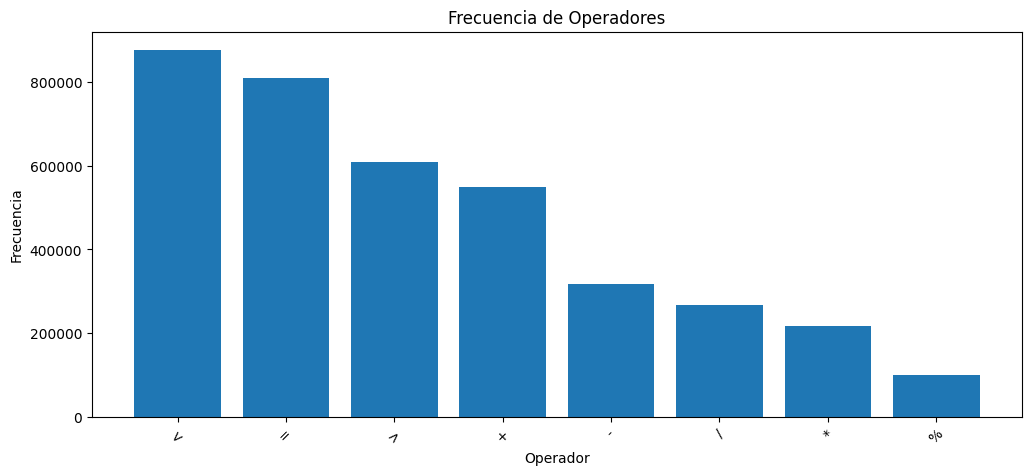

In [ ]:
tokens = [x[0] for x in top_operators]
freqs = [x[1] for x in top_operators]

plt.figure(figsize=(12,5))

plt.bar(tokens, freqs)

plt.xticks(rotation=45)

plt.xlabel("Operador")
plt.ylabel("Frecuencia")

plt.title("Frecuencia de Operadores")

plt.show()

In [ ]:
author_tokens = {}

for uid, group in df_merged.groupby('uid'):

    all_tokens = []

    for toks in group['tokens']:
        all_tokens.extend(toks)

    author_tokens[uid] = Counter(all_tokens)

sample_authors = list(author_tokens.keys())

for uid in author_tokens.keys():
    print(f"\nAUTOR ID: {uid}")
    for tok, freq in author_tokens[uid].most_common(10):
        print(f"  {tok}: {freq}")


AUTOR ID: 0
  -: 5670
  (: 5331
  ): 5041
  ;: 4617
  <: 4050
  =: 3845
  ,: 3421
  >: 3009
  t: 2669
  i: 2364

AUTOR ID: 1
  ;: 1530
  <: 1181
  >: 1145
  (: 1002
  ): 982
  =: 774
  #: 716
  int: 648
  [: 635
  ]: 635

AUTOR ID: 2
  ;: 1221
  (: 826
  ): 816
  =: 742
  +: 593
  [: 543
  ]: 543
  i: 497
  ,: 484
  int: 455

AUTOR ID: 3
  _: 1863
  <: 1108
  ;: 919
  .: 753
  (: 729
  ,: 729
  ): 727
  >: 618
  long: 527
  #: 464

AUTOR ID: 4
  ;: 716
  (: 530
  ): 530
  =: 414
  +: 389
  ,: 337
  i: 335
  ": 332
  n: 245
  int: 230

AUTOR ID: 5
  ;: 1035
  <: 806
  (: 720
  ): 718
  =: 565
  >: 480
  +: 439
  i: 394
  int: 353
  {: 347

AUTOR ID: 6
  ;: 1358
  (: 825
  ): 820
  =: 737
  int: 642
  ,: 602
  <: 586
  i: 580
  +: 543
  >: 528

AUTOR ID: 7
  (: 1850
  ): 1832
  ;: 1242
  ,: 1169
  #: 805
  <: 805
  >: 720
  =: 560
  int: 556
  i: 529

AUTOR ID: 8
  ;: 894
  =: 672
  (: 614
  ): 611
  i: 577
  [: 513
  ]: 512
  ,: 479
  +: 407
  ": 374

AUTOR ID: 9
  (: 1879
  ): 1871
  

CONSTRUIR DOCUMENTOS POR ARCHIVO

In [ ]:
file_tokens = defaultdict(list)

for _, row in df_merged.iterrows():

    file_tokens[row['file_id']].extend(
        row['tokens']
    )

docs = {
    fid: " ".join(tokens)
    for fid, tokens in file_tokens.items()
}

print("Total archivos:", len(docs))

Total archivos: 50000


In [ ]:
print("Total docs:", len(docs))
for k, v in list(docs.items())[:3]:
    print(f"  {k}: '{v[:100]}'")

Total docs: 50000
  27909: '[CLS] / * { { { * / # include < cs ##t ##dio > # include < cs ##t ##dl ##ib > # include < cs ##tri #'
  55938: '[CLS] / * { { { * / # include < cs ##t ##dio > # include < cs ##t ##dl ##ib > # include < cs ##tri #'
  90936: '[CLS] / * { { { * / # include < cs ##t ##dio > # include < cs ##t ##dl ##ib > # include < cs ##tri #'


In [ ]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    tokenizer=lambda x: x.split(),
    preprocessor=None,
    token_pattern=None,
    min_df=1
)

X = vectorizer.fit_transform(docs.values())
print(X.shape)

(50000, 9335)


In [ ]:
symbols = {'[CLS]','[SEP]','[PAD]','[UNK]','[MASK]',
           ';','(',')',',','<','>','=','+','-','*','/','.',
           '_','#','"',"'",'{','}','[',']','!','|','&','^','~','%','\\','@','`'}

top_token_per_author = {}
for uid, counter in author_tokens.items():
    for tok, freq in counter.most_common():
        if tok not in symbols:
            top_token_per_author[uid] = tok
            break

print(Counter(top_token_per_author.values()).most_common(15))

[('i', 532), ('int', 164), ('define', 92), ('include', 59), ('a', 33), ('x', 20), ('ll', 19), (':', 14), ('1', 13), ('n', 10), ('t', 7), ('long', 7), ('##f', 6), ('0', 5), ('typed', 3)]


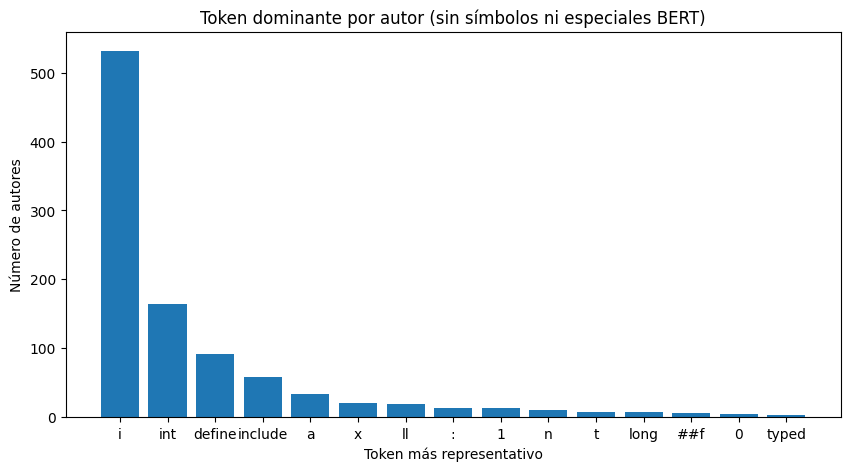

In [ ]:
top_counts = Counter(top_token_per_author.values()).most_common(15)

tokens = [x[0] for x in top_counts]
freqs  = [x[1] for x in top_counts]

plt.figure(figsize=(10, 5))
plt.bar(tokens, freqs)
plt.xlabel("Token más representativo")
plt.ylabel("Número de autores")
plt.title("Token dominante por autor (sin símbolos ni especiales BERT)")
plt.show()

In [ ]:
style_features = []

for uid, group in df_merged.groupby('uid'):
    all_toks = []
    for toks in group['tokens']:
        all_toks.extend(toks)

    total = len(all_toks)
    tok_set = set(all_toks)

    style_features.append({
        'uid': uid,

        'usa_snake_case': int('_' in tok_set),
        'usa_camel_case': int(any('##' in t and t[2].isupper()
                                  for t in all_toks)),
        'frecuencia_underscore': all_toks.count('_') / total,

        'usa_hex': int(any(t.startswith('0x') or t.startswith('0X')
                          for t in all_toks)),
        'usa_ll': int('ll' in tok_set),
        'frecuencia_ll': all_toks.count('ll') / total,

        'usa_define': int('define' in tok_set),
        'frecuencia_define': all_toks.count('define') / total,

        'ratio_puntoycoma': all_toks.count(';') / total,
        'ratio_parentesis':  (all_toks.count('(') + all_toks.count(')')) / total,
        'ratio_angulares':   (all_toks.count('<') + all_toks.count('>')) / total,

        'usa_class':     int('class' in tok_set),
        'usa_template':  int('template' in tok_set),
        'usa_namespace': int('namespace' in tok_set),
        'usa_vector':    int('vector' in tok_set),
        'usa_include':   int('include' in tok_set),
    })

style_df = pd.DataFrame(style_features).set_index('uid')
print(style_df.describe())

       usa_snake_case  usa_camel_case  frecuencia_underscore  usa_hex  \
count     1000.000000          1000.0            1000.000000   1000.0   
mean         0.999000             0.0               0.013651      0.0   
std          0.031623             0.0               0.015183      0.0   
min          0.000000             0.0               0.000000      0.0   
25%          1.000000             0.0               0.006183      0.0   
50%          1.000000             0.0               0.009947      0.0   
75%          1.000000             0.0               0.015550      0.0   
max          1.000000             0.0               0.263217      0.0   

            usa_ll  frecuencia_ll   usa_define  frecuencia_define  \
count  1000.000000    1000.000000  1000.000000        1000.000000   
mean      0.941000       0.006658     0.938000           0.011500   
std       0.235743       0.006528     0.241276           0.011254   
min       0.000000       0.000000     0.000000           0.000000 

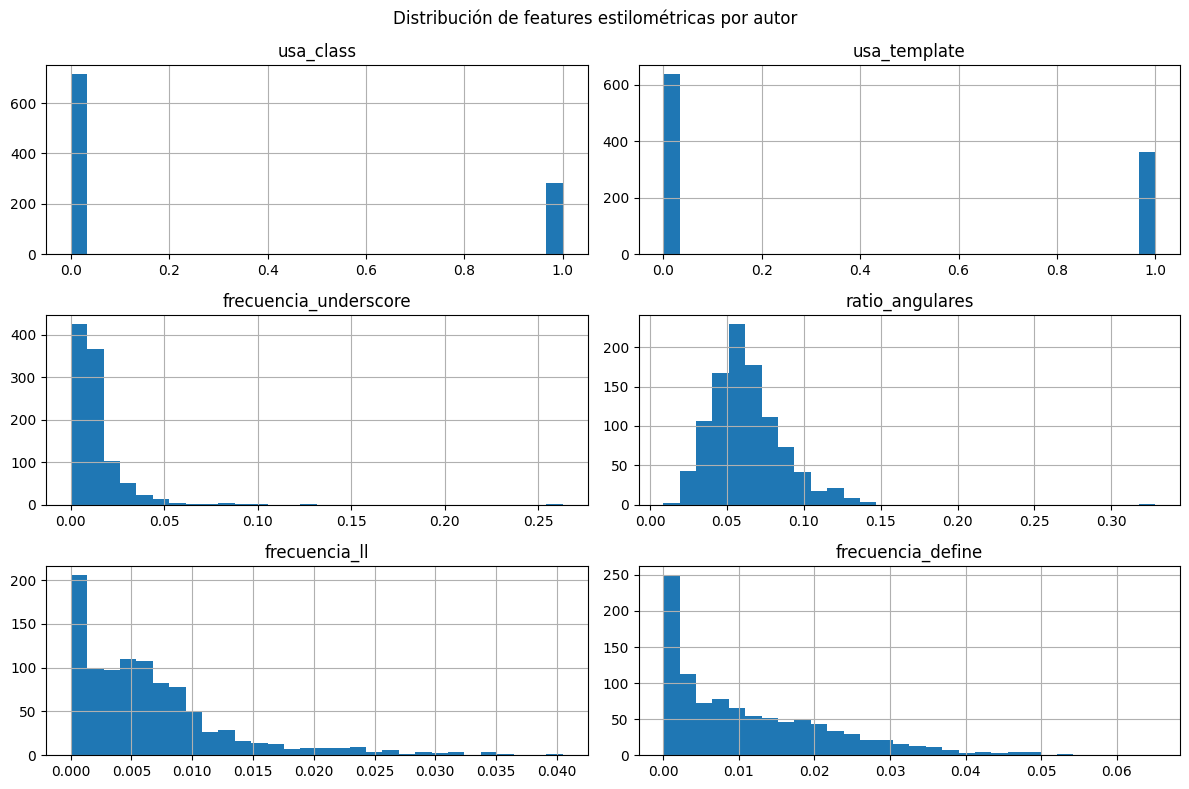

In [ ]:

useful_features = ['usa_class', 'usa_template',
                   'frecuencia_underscore', 'ratio_angulares',
                   'frecuencia_ll', 'frecuencia_define']

style_df[useful_features].hist(bins=30, figsize=(12, 8))
plt.suptitle('Distribución de features estilométricas por autor')
plt.tight_layout()
plt.show()

# Conclusión
El análisis exploratorio de datos realizado permitió identificar patrones relacionados con la estructura, el estilo y la distribución del código. A partir del análisis de frecuencias, tokenización y extracción de características, se observó que los programas contienen suficientes patrones sintácticos para diferenciar estilos de programación y detectar similitudes entre archivos.

El dataset está equilibrado, como podemos observar en la cantidad de archivos y autores. Al momento de analizar los estilos, se puede observar que pocos programas usan template o class, lo que podría indicar que algunos autores sí diseñan su código o priorizan la modularidad. También se observa que los autores no usan mucho el guion bajo (_), lo que sugiere que prefieren utilizar camelCase para escribir código. Además, posiblemente los autores no realizan condicionales tan complejas al no usar tantos operadores OR. Finalmente, no muchos utilizan define, lo que significa que pocos autores emplean preprocesamiento en los archivos de C.

Por lo anterior, podrían existir problemas con el modelo, ya que, aunque se obtienen patrones, estos son muy generales y corresponden únicamente a ciertas secciones específicas. Esto podría facilitar la identificación de algunos autores, pero no de la mayoría.